# CA5 Pepper Spiciness Prediction

### Imports

In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_predict
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, accuracy_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

### Reading data

In [68]:
# Reading the train and test data
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')

### Data exploration and visualisation

In [69]:
# Exploring what datatypes there are in the dataset.
df_train.dtypes

Length (cm)                                          float64
Width (cm)                                           float64
Weight (g)                                           float64
Pericarp Thickness (mm)                              float64
Seed Count                                           float64
Capsaicin Content                                    float64
Vitamin C Content (mg)                               float64
Sugar Content                                        float64
Moisture Content                                     float64
Firmness                                             float64
color                                                 object
Harvest Time                                          object
Average Daily Temperature During Growth (celcius)    float64
Average Temperature During Storage (celcius)          object
Scoville Heat Units (SHU)                            float64
dtype: object

Since it is both categorical and numerical datatypes, i will have to encode the categorical values.

In [70]:
# Checking if there are any missing values/NaN's in the dataset. 
df_train.isna().sum()

Length (cm)                                            1
Width (cm)                                             1
Weight (g)                                             1
Pericarp Thickness (mm)                                2
Seed Count                                             1
Capsaicin Content                                      1
Vitamin C Content (mg)                                 0
Sugar Content                                          1
Moisture Content                                       0
Firmness                                               1
color                                                  1
Harvest Time                                           0
Average Daily Temperature During Growth (celcius)      0
Average Temperature During Storage (celcius)         648
Scoville Heat Units (SHU)                              0
dtype: int64

I am removing the 'Average temperature During Storage (celsius)' because it is mostly missing values. The rest of the missing values I will have to impute.

In [71]:
# Removing 'Average Temperature During Storage (celsius)' from train_df
train_df = df_train.drop('Average Temperature During Storage (celcius)', axis=1)

In [72]:
# Sorting the cols with numerical and categorical values, and removing the target
cat_cols = train_df.select_dtypes(include=['object']).columns[:-1].to_list()
num_cols = train_df.select_dtypes(include=['float64']).columns[:-1].to_list()
num_df = train_df[num_cols]

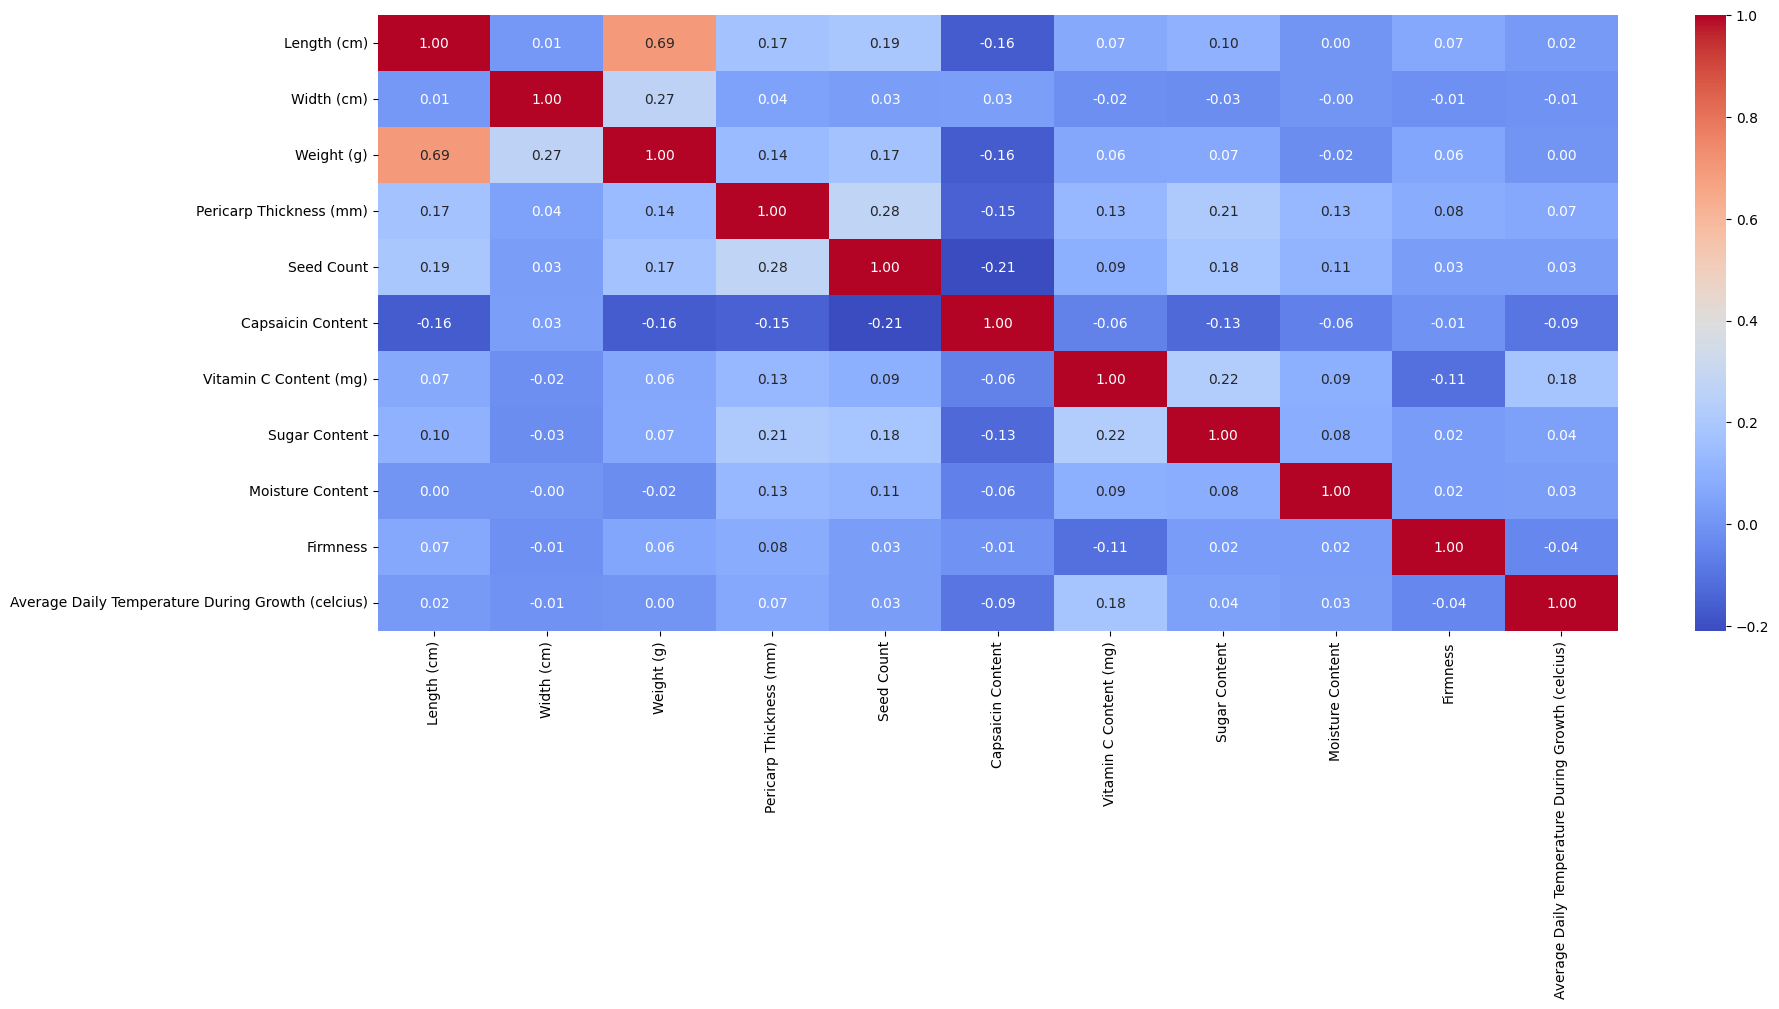

In [73]:
# Correlation heatmap of the dataset
plt.figure(figsize=(20, 8))
hm = sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')

Some features in the dataset are correclated significally more to eachother than the rest. I am handling this by using PCA during the preprocessing.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Length (cm)'),
  Text(1, 0, 'Width (cm)'),
  Text(2, 0, 'Weight (g)'),
  Text(3, 0, 'Pericarp Thickness (mm)'),
  Text(4, 0, 'Seed Count'),
  Text(5, 0, 'Capsaicin Content'),
  Text(6, 0, 'Vitamin C Content (mg)'),
  Text(7, 0, 'Sugar Content'),
  Text(8, 0, 'Moisture Content'),
  Text(9, 0, 'Firmness'),
  Text(10, 0, 'Average Daily Temperature During Growth (celcius)')])

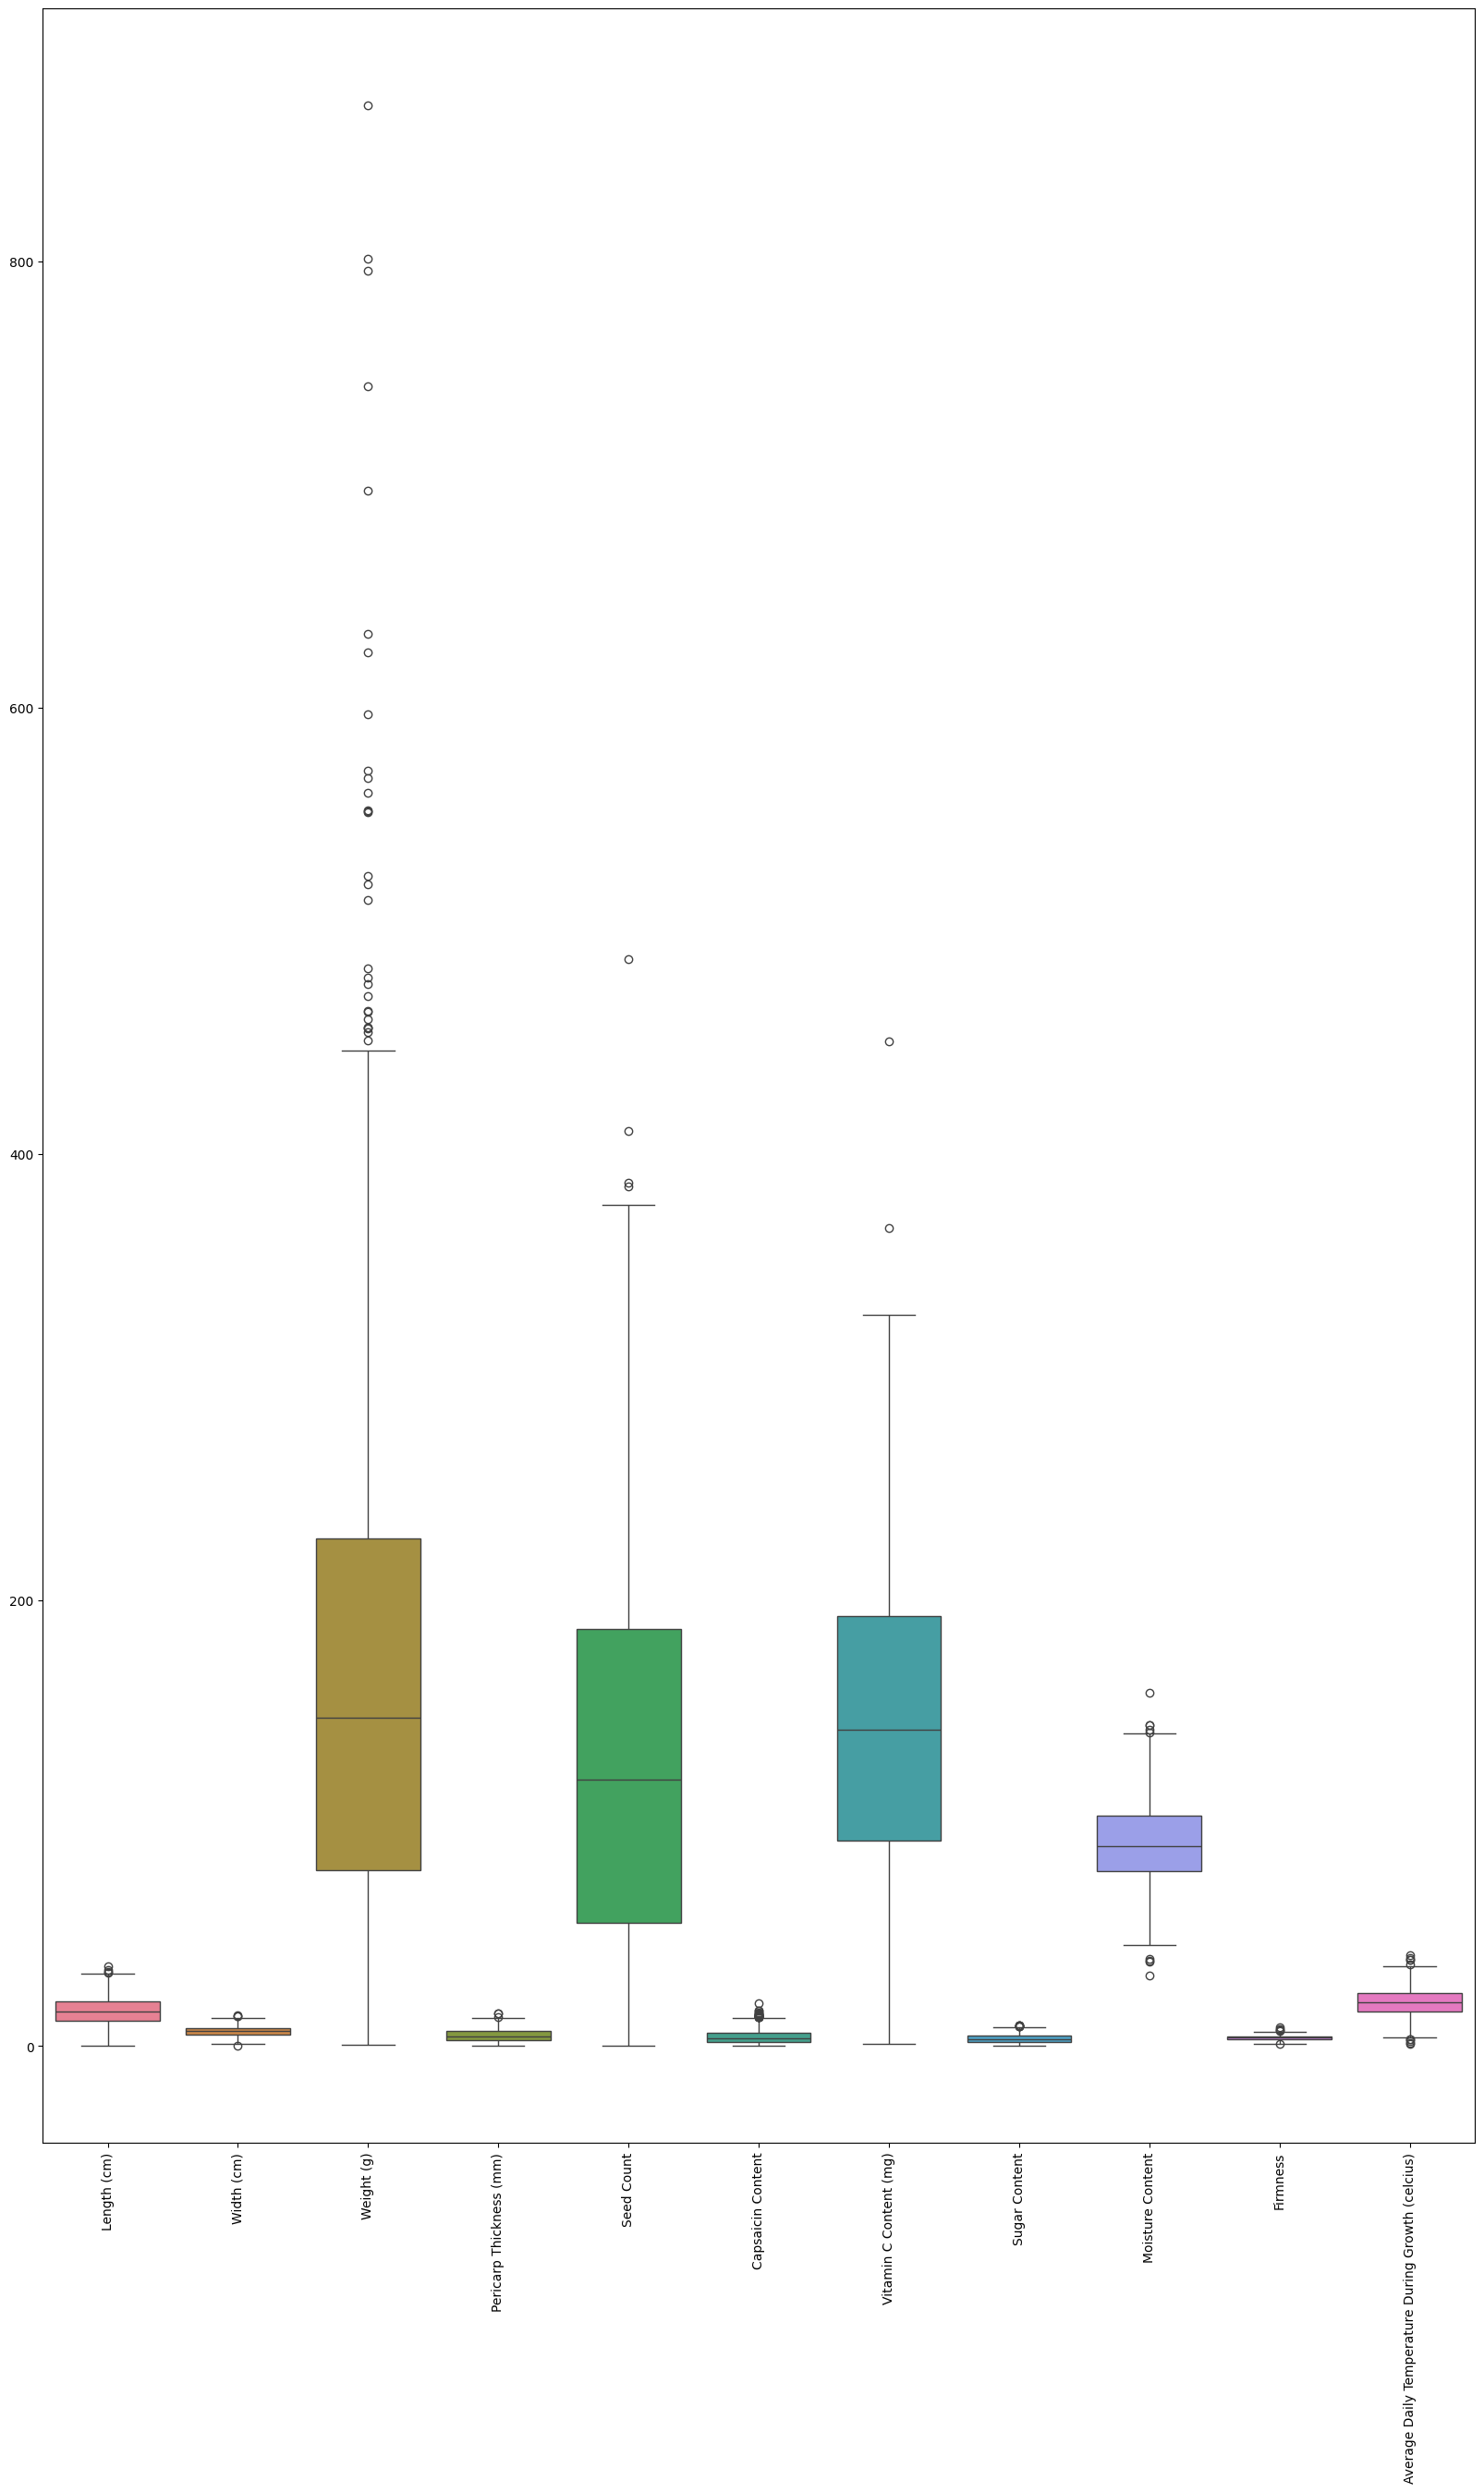

In [74]:
# Boxplot for the numerical features
plt.figure(figsize=(20, 30))
sns.boxplot(num_df)
plt.xticks(rotation=90)

array([[<Axes: title={'center': 'Length (cm)'}>,
        <Axes: title={'center': 'Width (cm)'}>,
        <Axes: title={'center': 'Weight (g)'}>],
       [<Axes: title={'center': 'Pericarp Thickness (mm)'}>,
        <Axes: title={'center': 'Seed Count'}>,
        <Axes: title={'center': 'Capsaicin Content'}>],
       [<Axes: title={'center': 'Vitamin C Content (mg)'}>,
        <Axes: title={'center': 'Sugar Content'}>,
        <Axes: title={'center': 'Moisture Content'}>],
       [<Axes: title={'center': 'Firmness'}>,
        <Axes: title={'center': 'Average Daily Temperature During Growth (celcius)'}>,
        <Axes: title={'center': 'Scoville Heat Units (SHU)'}>]],
      dtype=object)

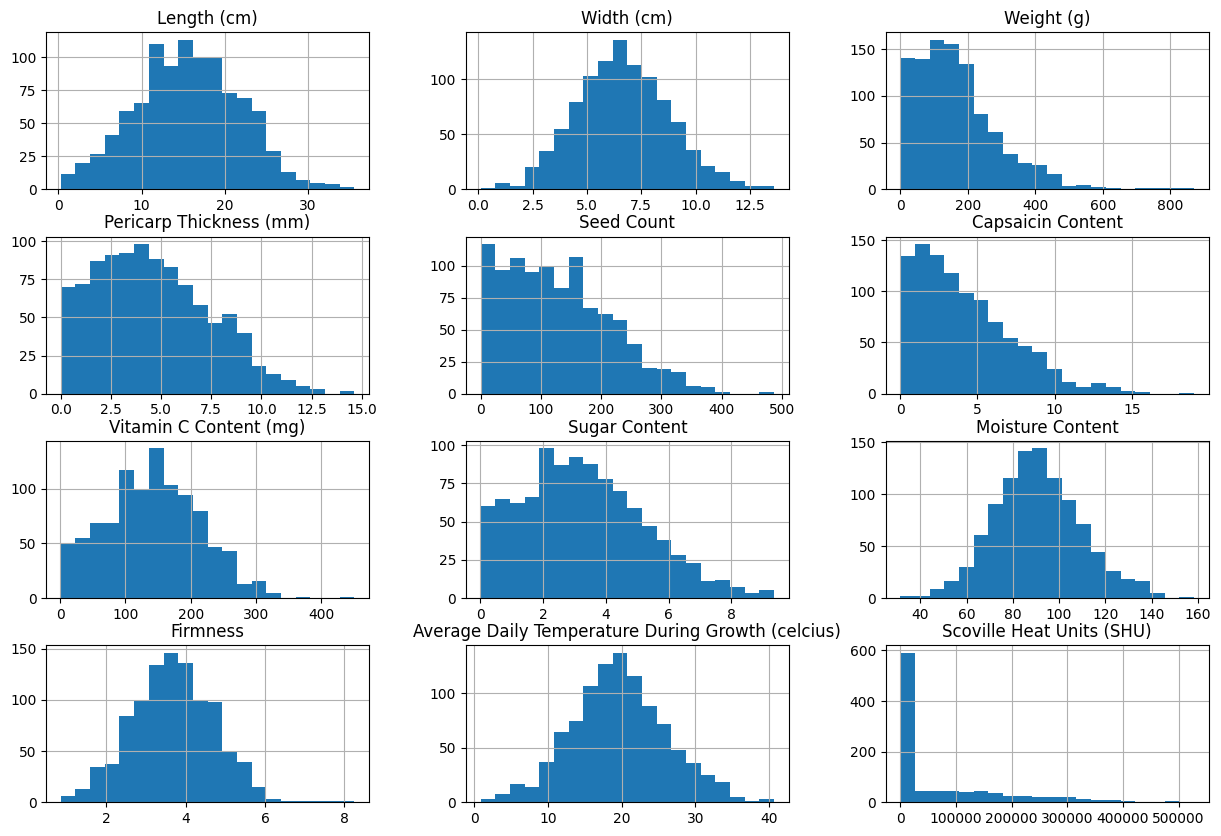

In [33]:
# Histogram of the features in the dataset
train_df.hist(bins=20, figsize=(15, 10))

**Outliers**
The boxplot and histogram plot shows there are relatively few outliers in the dataset. Most of the outliers are under the 'Weight (g)' feature. There are also outliers under the features 'Vitamin C Content (mg)' and 'Seed count'. I am not removing any outliers from the data, because I think this will remove patterns in the data and the representation of how the data really is. Also, not removing outliers makes my model more prepared to face outliers in datasets it has not been trained on. These are important things, having in mind that I want a model that generalizes well on unseen data. 

### Data preprocessing

In [90]:
# Defining features and target.
X = train_df.drop('Scoville Heat Units (SHU)', axis=1)
y = train_df['Scoville Heat Units (SHU)']

# Splitting data in tran and test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Sorting the numerical and categorical columns.
num_cols = X_train.select_dtypes(include=['float64']).columns.to_list()
cat_cols = X_train.select_dtypes(include=['object']).columns.to_list()

In [91]:
# Pipeline to preprocesses the numerical data
num_trans = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=1))
])

# Pipeline to preprocess the categorical data
cat_trans = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocessor that scale and apply pca to numerical data, encodes categorical data
# and imputes both datatypes. 
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', num_trans, num_cols),
        ('categorical', cat_trans, cat_cols)
    ])

### Modelling

**Pipeline A**

In [95]:
# PCR pipeline 
pcr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Cross validation prediction of model.
y_hat = cross_val_predict(pcr_pipeline, X_train, y_train, cv=5)

# Printing mean absolute error of model.
error = mean_absolute_error(y_train, y_hat)
print("Mean absolute error: ", error)

Mean absolute error:  76204.64103142249


In [96]:
# Hyperparameter tuning for the PCR pipeline

pcr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Parameter grid for the pcr pipeline.
pcr_param_grid = {
    'preprocessor__numerical__imputer__strategy' : ['mean', 'median'],
    'preprocessor__numerical__pca__n_components' : [1, 2, 3],
    'preprocessor__categorical__imputer__strategy' : ['most_frequent', 'constant'],
    'model__fit_intercept' : [True, False],
}

# Splitting dataset into 5 folds for grid search
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search over 5-fold cross validation defined by cv.
pcr_gridsearch = GridSearchCV(estimator=pcr_pipeline, param_grid=pcr_param_grid, cv=cv, verbose=1)

# Fitting grid search to training data
pcr_gridsearch.fit(X_train, y_train)

# Printing out the best parameters from the grid search.
print('Best parameters: ', pcr_gridsearch.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters:  {'model__fit_intercept': True, 'preprocessor__categorical__imputer__strategy': 'most_frequent', 'preprocessor__numerical__imputer__strategy': 'mean', 'preprocessor__numerical__pca__n_components': 3}


In [94]:
# Evaluation of pcr-model after hyperparameter tuning. 
best_pcr = pcr_gridsearch.best_estimator_
y_pred = best_pcr.predict(X_test)
mean_absolute_error_ = mean_absolute_error(y_test, y_pred)
print(f'Mean absolute error: ', mean_absolute_error_)

Mean absolute error:  66749.29483632669


**Pipeline C**

In [114]:
# Pipeline to preprocesses the numerical data
num_trans = Pipeline(
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
)

# Pipeline to preprocess the categorical data
cat_trans = Pipeline(
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
)

# Preprocessor that scale numerical data, encode categorical data
# and imputes both datatypes.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_trans, num_cols),
        ('cat', cat_trans, cat_cols)
    ])

In [126]:
# Split data in train and test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline for the classification model
clf_pipeline = Pipeline([
    ('preprocesor', preprocessor),
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier())
])

# Parameter grid for the classifier
clf_param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 10, 20, 30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4]
}

# Splitting dataset to 5 folds for the gridsearch.
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search over 5-fold cross validation defined by cv.
clf_gridsearch = GridSearchCV(clf_pipeline, clf_param_grid, cv=cv, scoring='neg_mean_absolute_error', verbose=1)

# Fitting gridsearch to trainig data. 
clf_gridsearch.fit(X_train, (y_train > 0).astype(int))


# Printing out best parametersthe grid search.
y_pred_class = clf_gridsearch.predict(X_test)
print('Best parameters: ', clf_gridsearch.best_params_)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters:  {'rf__max_depth': 30, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 10, 'rf__n_estimators': 300}


In [135]:

# Identifying the spicy peppers
spicy_peppers = y_train > 0
X_train_spicy, y_train_spicy = X_train[spicy_peppers], y_train[spicy_peppers]
X_test_spicy, y_test_spicy = X_test[y_test > 0], y_test[y_test > 0]

# Pipeline for the regression
reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('reg', RandomForestRegressor(n_estimators=100, random_state=42))
])

# The parameter grid for the regression model
reg_param_grid= {
    'reg__n_estimators' : [100, 200, 300],
    'reg__max_depth' : [None, 10, 20, 30],
    'reg__min_samples_split' : [2, 5, 10],
    'reg__min_samples_leaf' : [1, 2, 4]
}

# Splitting dataset to 5 folds for the gridsearch.
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search over 5-fold cross validation defined by cv.
reg_gridsearch = GridSearchCV(reg_pipeline, reg_param_grid, cv=cv, scoring='neg_mean_absolute_error', verbose=1)

# Fitting the gridsearch to training data
reg_gridsearch.fit(X_train_spicy, y_train_spicy)

# Printing out the best parameters from the grid search.
print('Best parameters: ', reg_gridsearch.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters:  {'reg__max_depth': None, 'reg__min_samples_leaf': 4, 'reg__min_samples_split': 10, 'reg__n_estimators': 300}


In [134]:
# Evaluating the best classifier
best_clf = clf_gridsearch.best_estimator_
y_pred_clf = best_clf.predict(X_test)
accuracy = accuracy_score(y_test > 0, y_pred_clf)
print(f"Classification accuracy: {accuracy:.2f}")

# Evaluating the best regressor
best_reg = reg_gridsearch.best_estimator_
y_pred_reg = best_reg.predict(X_test_spicy)
mae = mean_absolute_error(y_test_spicy, y_pred_reg)
print(f"Mean absolute error: {mae:.2f}")

Classification accuracy: 0.90
Mean absolute error: 88063.58


### Final evaluation

**Final evaluation of pipeline A**

In [ ]:
# Fitting the best pcr model to the whole training dataset.
best_pcr.fit(X, y)
# Predicting with the best pcr.model on the test dataset.
y_pred = best_pcr.predict(df_test)

**Final evaluation of Pipeline C**

In [143]:
# Classifying between bell peppers and spicy peppers
final_class_pred = best_clf.predict(df_test)

# Initializing a vector to store the predictions in, and final regression
# on the spicy peppers.
vector = np.zeros(len(final_class_pred)) 
final_reg_pred = best_reg.predict(df_test[final_class_pred > 0])
vector[final_class_pred > 0] = final_reg_pred

### Kaggle submission

In [142]:
# Creating Kaggle submission .csv-file.
y_hat = pd.DataFrame(vector, columns=['Scoville Heat Units (SHU)'])
y_hat.index.name = "index"
y_hat.to_csv("predictions2.csv")